# Statistics

<img src="./img/3_statistics.png">
<br><br>

##### Def 1:

> &nbsp;  
> Statistics is a branch of `applied mathematics` that involves
> 
> - the collection
> - description
> - analysis and
> - inference of conclusions
>  
> from `quantitative data`.
> <br><br>

##### Def 2:

> &nbsp;  
> _There are lies, damned lies and statistics._
> <br><br>

<span style="font-size: 70%">(M.Twain)</span>



In [1]:
# some imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

### Description of data

In [2]:
# assume some data

num_friends = [100.0, 49, 41, 40, 25, 21, 21, 19, 19, 18, 18, 16, 15, 15, 15, 15, 14, 14, 13, 13, 13, 13, 12, 12, 11, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6,
               6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


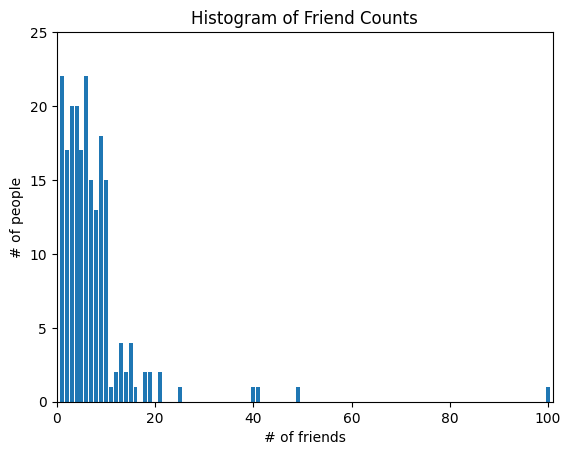

In [3]:
# visualize this data

friend_counts = Counter(num_friends)

# prepare data
x_range = int(max(num_friends)+1)                       # max = 100.0 but range needs int
xs = range(x_range)
ys = [friend_counts[x] for x in xs]
y_range = max(ys) + 3                                   # max ys = 22

# plot data
plt.bar(xs, ys)
plt.axis([0, x_range, 0, y_range])
plt.title("Histogram of Friend Counts")
plt.xlabel("# of friends")
plt.ylabel("# of people")
plt.show()

In [4]:
# describe data set

print(f"Number of data points: {len(num_friends)}")
print(f"Max number of friends: {max(num_friends)}")
print(f"Min number of friends: {min(num_friends)}")
print(f"Mean no. of friends:   {np.mean(num_friends)}")
print(f"Standard deviation:    {np.std(num_friends)}")

Number of data points: 204
Max number of friends: 100.0
Min number of friends: 1
Mean no. of friends:   7.333333333333333
Standard deviation:    9.007984838446012


The `Median` is the midpoint of the sorted array.

For a 5-value vector $\left( x_1, x_2, x_3, x_4, x_5 \right)$, that would be $x_3$.  

For a 6-value vector $(x_1, x_2, x_3, x_4, x_5, x_6)$, that would be $\frac {x_3 + x_4}{2}$.

In [5]:
# calculating the median (in Python)

from typing import List

# The underscores indicate that these are "private" functions, as they're
# intended to be called by our median function but not by other people
# using our statistics library.

def _median_odd(xs: List[float]) -> float:
    """If len(xs) is odd, the median is the middle element"""
    return sorted(xs)[len(xs) // 2]


def _median_even(xs: List[float]) -> float:
    """If len(xs) is even, it's the average of the middle two elements"""
    sorted_xs = sorted(xs)
    hi_midpoint = len(xs) // 2  # e.g. length 4 => hi_midpoint 2
    return (sorted_xs[hi_midpoint - 1] + sorted_xs[hi_midpoint]) / 2


def median(v: List[float]) -> float:
    """Finds the 'middle-most' value of v"""
    return _median_even(v) if len(v) % 2 == 0 else _median_odd(v)

assert median([1, 10, 2, 9, 5]) == 5
assert median([1, 9, 2, 10]) == (2 + 9) / 2

In [6]:
# quantiles represent the boundary unter which a certain percentile of data lies

def quantile(xs: List[float], p: float) -> float:
    """Returns the pth-percentile value in x"""
    p_index = int(p * len(xs))
    return sorted(xs)[p_index]

# 10% of data lies under this value
assert quantile(num_friends, 0.10) == 1
# 25% of data below 3
assert quantile(num_friends, 0.25) == 3
assert quantile(num_friends, 0.75) == 9
assert quantile(num_friends, 0.90) == 13


In [7]:
# using numpy

assert np.median([1, 10, 2, 9, 5]) == 5.0
assert np.median([1, 9, 2, 10]) == (2 + 9) / 2

print(f"Median no. of friends: {np.median(num_friends)}")


Median no. of friends: 6.0


array([[<Axes: title={'center': '0'}>]], dtype=object)

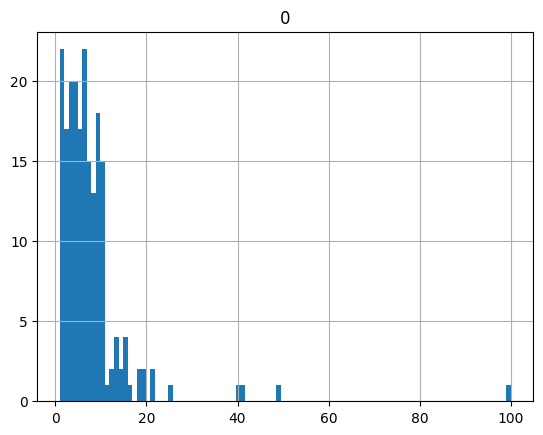

In [8]:
# using pandas

df = pd.DataFrame(num_friends)
df.hist(bins=100)

In [9]:
# describe the dataset
# median is the 50% percentile

df.describe()

,0
count,204.000000
mean,7.333333
std,9.030145
min,1.000000
25%,3.000000
50%,6.000000
75%,9.000000
max,100.000000


array([[<Axes: title={'center': '0'}>]], dtype=object)

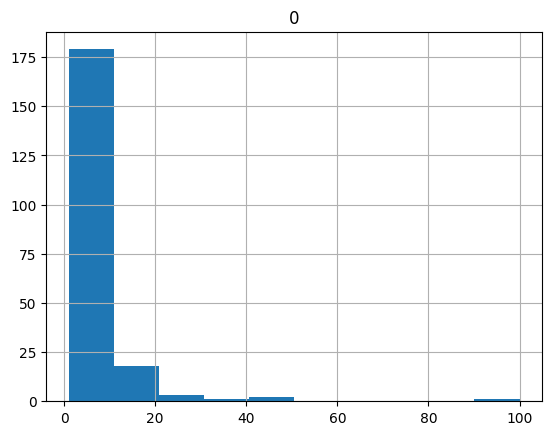

In [10]:
# using different bin sizes

df.hist(bins=10)

In [40]:
# address individual metrical values using array addressing

print(f"25% quantile: {df.describe().values[4]}")
print(f"Std: {df.describe()[0]['std']}")

25% quantile: [3.]
Std: 9.030144736232474


### Data distribution

##### Variance

In [ ]:
# variance

def de_mean(xs: List[float]) -> List[float]:
    """Translate xs by subtracting its mean (so the result has mean 0)"""
    x_bar = np.mean(xs)
    return [x - x_bar for x in xs]


def variance(xs: List[float]) -> float:
    """Almost the average squared deviation from the mean"""
    assert len(xs) >= 2, "variance requires at least two elements"

    n = len(xs)
    deviations = de_mean(xs)
    return sum(np.square(deviations)) / (n - 1)             # apply Bessel's correction

assert 81.54 < variance(num_friends) < 81.55

print(variance(num_friends))


The variance in `NumPy` is calculated as

$ var(X) = \left( \left| x_i - \bar{x} \right| \right)^{2} $

which resembles the _unbiased variance_ (s. [Wikipedia on unbiased standard deviation](https://en.wikipedia.org/wiki/Unbiased_estimation_of_standard_deviation)). 

In [ ]:
# in numpy

np.var(num_friends)

##### Standard deviation

In [ ]:
# standard deviation

np.std(num_friends)

##### Covariance

_Variance_ measures the deviation from the mean,  

_Covariance_ indicates the level to which two variables vary together. If we examine N-dimensional samples,

$ X = \left[ x_1, x_2, \cdots , x_N \right]^T $, 

then the covariance matrix element $C_{ij}$ is the covariance of $x_i$ and $x_j$. The element $C_{ii}$ is the variance of $x_i$.

In [ ]:

daily_minutes = [1, 68.77, 51.25, 52.08, 38.36, 44.54, 57.13, 51.4, 41.42, 31.22, 34.76, 54.01, 38.79, 47.59, 49.1, 27.66, 41.03, 36.73, 48.65, 28.12, 46.62, 35.57, 32.98, 35, 26.07, 23.77, 39.73, 40.57, 31.65, 31.21, 36.32, 20.45, 21.93, 26.02, 27.34, 23.49, 46.94, 30.5, 33.8, 24.23, 21.4, 27.94, 32.24, 40.57, 25.07, 19.42, 22.39, 18.42, 46.96, 23.72, 26.41, 26.97, 36.76, 40.32, 35.02, 29.47, 30.2, 31, 38.11, 38.18, 36.31, 21.03, 30.86, 36.07, 28.66, 29.08, 37.28, 15.28, 24.17, 22.31, 30.17, 25.53, 19.85, 35.37, 44.6, 17.23, 13.47, 26.33, 35.02, 32.09, 24.81, 19.33, 28.77, 24.26, 31.98, 25.73, 24.86, 16.28, 34.51, 15.23, 39.72, 40.8, 26.06, 35.76, 34.76, 16.13, 44.04, 18.03, 19.65, 32.62,
                 35.59, 39.43, 14.18, 35.24, 40.13, 41.82, 35.45, 36.07, 43.67, 24.61, 20.9, 21.9, 18.79, 27.61, 27.21, 26.61, 29.77, 20.59, 27.53, 13.82, 33.2, 25, 33.1, 36.65, 18.63, 14.87, 22.2, 36.81, 25.53, 24.62, 26.25, 18.21, 28.08, 19.42, 29.79, 32.8, 35.99, 28.32, 27.79, 35.88, 29.06, 36.28, 14.1, 36.63, 37.49, 26.9, 18.58, 38.48, 24.48, 18.95, 33.55, 14.24, 29.04, 32.51, 25.63, 22.22, 19, 32.73, 15.16, 13.9, 27.2, 32.01, 29.27, 33, 13.74, 20.42, 27.32, 18.23, 35.35, 28.48, 9.08, 24.62, 20.12, 35.26, 19.92, 31.02, 16.49, 12.16, 30.7, 31.22, 34.65, 13.13, 27.51, 33.2, 31.57, 14.1, 33.42, 17.44, 10.12, 24.42, 9.82, 23.39, 30.93, 15.03, 21.67, 31.09, 33.29, 22.61, 26.89, 23.48, 8.38, 27.81, 32.35, 23.84]
daily_hours = [dm / 60 for dm in daily_minutes]

In [ ]:
def covariance(xs: List[float], ys: List[float]) -> float:
    assert len(xs) == len(ys), "xs and ys must have same number of elements"

    # dot = x_i * y_i with x_i and y_i normalized around mean, result Bessel corrected
    return np.dot(de_mean(xs), de_mean(ys)) / (len(xs) - 1)

assert 22.42 < covariance(num_friends, daily_minutes) < 22.43
assert 22.42 / 60 < covariance(num_friends, daily_hours) < 22.43 / 60

covariance(num_friends, daily_minutes)

In [ ]:
# in numpy

X = np.stack((num_friends, daily_minutes))
np.cov(X)

In [ ]:
# covariance between x_i and y_i

np.cov(X)[0][1]

##### Correlation

In [ ]:
def correlation(xs: List[float], ys: List[float]) -> float:
    """Measures how much xs and ys vary in tandem about their means"""
    stdev_x = np.std(xs)
    stdev_y = np.std(ys)
    if stdev_x > 0 and stdev_y > 0:
        return covariance(xs, ys) / stdev_x / stdev_y
    else:
        return 0    # if no variation, correlation is zero

assert 0.24 < correlation(num_friends, daily_minutes) < 0.25
assert 0.24 < correlation(num_friends, daily_hours) < 0.25

In [ ]:
# in numpy

np.corrcoef(num_friends, daily_minutes)

In [ ]:
# correlation between x_i and y_i

np.corrcoef(num_friends, daily_minutes)[0][1]

In [ ]:
# visualze correlation

plt.scatter(num_friends, daily_minutes)
plt.show()

Correlations are sensitive to outliers (index 100 is an outlier).

In [ ]:
# if we eliminate the outlier, data correlates better

outlier = num_friends.index(100)    # index of outlier

num_friends_good = [x
                    for i, x in enumerate(num_friends)
                    if i != outlier]

daily_minutes_good = [x
                      for i, x in enumerate(daily_minutes)
                      if i != outlier]

np.corrcoef(num_friends_good, daily_minutes_good)[0][1]

In [ ]:
plt.scatter(num_friends_good, daily_minutes_good)
plt.show()

In [ ]:
type(X)

In [ ]:
# let's save this data for later use

np.savetxt('data/Friends.csv',
            np.array([num_friends_good, daily_minutes_good]).T,
            fmt='%-.0f,%-3.2f',
            header='friends,daily_minutes',
            comments='')


<table>
<tr>
<td style="border-style: none"><img src="./img/0_reference.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><u>Further reading:</u>
<ul>
<li>Chapter 5 (p 92ff) from "Data Science from Scratch"</li>
<li><a href="https://numpy.org/doc/stable/reference/routines.statistics.html">NumPy statistics</a></li>
</ul>
</td>
</tr>
</table>

<table>
<tr>
<td style="border-style: none"><img src="./img/0_students_input.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><h5>Students task:</h5>Discuss Correlation and Causation (same or contradiction).</td>
</tr>
</table>